<a href="https://colab.research.google.com/github/Vickramabharathi/MLA0204-Fundamentals-of-Machine-Learning/blob/main/Practical_Problems_Outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1.Implement and demonstrate the FIND-S algorithm
for finding the most specific hypothesis based on a given set of training data
samples.**

In [ ]:
import pandas as pd
from google.colab import files

# Upload CSV
uploaded = files.upload()

# Read CSV
data = pd.read_csv("training_data1.csv")

print("Training Dataset:\n")
print(data)

# Initialize hypothesis
hypothesis = ['0'] * (len(data.columns) - 1)

# Find-S Algorithm
for _, row in data.iterrows():
    if row["EnjoySport"] == "Yes":
        for i in range(len(hypothesis)):
            if hypothesis[i] == '0':
                hypothesis[i] = row.iloc[i]
            elif hypothesis[i] != row.iloc[i]:
                hypothesis[i] = '?'

print("\nMost Specific Hypothesis:")
print(hypothesis)

Saving training_data1.csv to training_data1.csv
Training Dataset:

     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes
4  Sunny    Warm   Normal    Weak  Warm     Same        Yes
5  Sunny    Warm     High    Weak  Warm     Same        Yes
6  Rainy    Cold   Normal  Strong  Cold   Change         No
7  Sunny    Warm   Normal  Strong  Cool     Same        Yes

Most Specific Hypothesis:
['Sunny', 'Warm', '?', '?', '?', '?']


**2.For a given set of training data examples storedin a .CSV file, implement and demonstrate the Candidate-Elimination algorithm in python to output a  description of the set of all hypotheses consistent with the training examples.**

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Read dataset
data = pd.read_csv("training_data1.csv")

print("Training Dataset:\n")
print(data)

# Convert dataset into numpy array
concepts = np.array(data.iloc[:, :-1])
target = np.array(data.iloc[:, -1])

# Candidate Elimination Algorithm
def candidate_elimination(concepts, target):

    specific_h = concepts[0].copy()
    general_h = [["?" for _ in range(len(specific_h))] for _ in range(len(specific_h))]

    print("\nInitial Specific Hypothesis:")
    print(specific_h)

    print("\nInitial General Hypothesis:")
    print(general_h)

    for i, h in enumerate(concepts):

        if target[i].lower() == "yes":

            for x in range(len(specific_h)):
                if h[x] != specific_h[x]:
                    specific_h[x] = "?"
                    general_h[x][x] = "?"

        if target[i].lower() == "no":

            for x in range(len(specific_h)):
                if h[x] != specific_h[x]:
                    general_h[x][x] = specific_h[x]
                else:
                    general_h[x][x] = "?"

    # Remove overly general hypotheses
    final_general = []

    for row in general_h:
        if row != ["?" for _ in range(len(specific_h))]:
            final_general.append(row)

    return specific_h, final_general


S, G = candidate_elimination(concepts, target)

print("\nFinal Specific Hypothesis:")
print(S)

print("\nFinal General Hypothesis:")
for g in G:
    print(g)

Saving training_data1.csv to training_data1.csv
Training Dataset:

     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes
4  Sunny    Warm   Normal    Weak  Warm     Same        Yes
5  Sunny    Warm     High    Weak  Warm     Same        Yes
6  Rainy    Cold   Normal  Strong  Cold   Change         No
7  Sunny    Warm   Normal  Strong  Cool     Same        Yes

Initial Specific Hypothesis:
['Sunny' 'Warm' 'Normal' 'Strong' 'Warm' 'Same']

Initial General Hypothesis:
[['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?'], ['?', '?', '?', '?', '?', '?']]

Final Specific Hypothesis:
['Sunny' 'Warm' '?' '?' '?' '?']

Final General Hypothesis:
['Su

**3.Demonstrate the working of the decision tree based ID3 algorithm. Use an appropriate data set for building the decision tree and apply this knowledge to classify a new sample.**

Dataset:
     Outlook Temperature Humidity    Wind Target
0      sunny         hot     high    weak     no
1      sunny         hot     high  strong     no
2   overcast         hot     high    weak    yes
3       rain        mild     high    weak    yes
4       rain        cool   normal    weak    yes
5       rain        cool   normal  strong     no
6   overcast        cool   normal  strong    yes
7      sunny        mild     high    weak     no
8      sunny        cool   normal    weak    yes
9       rain        mild   normal    weak    yes
10     sunny        mild   normal  strong    yes
11  overcast        mild     high  strong    yes
12  overcast         hot   normal    weak    yes
13      rain        mild     high  strong     no

Information Gain:
Outlook = 0.2467
Temperature = 0.0292
Humidity = 0.1518
Wind = 0.0481

New Sample:
   Outlook_overcast  Outlook_rain  Outlook_sunny  Temperature_cool  \
0             False         False           True              True   

   Temperatur

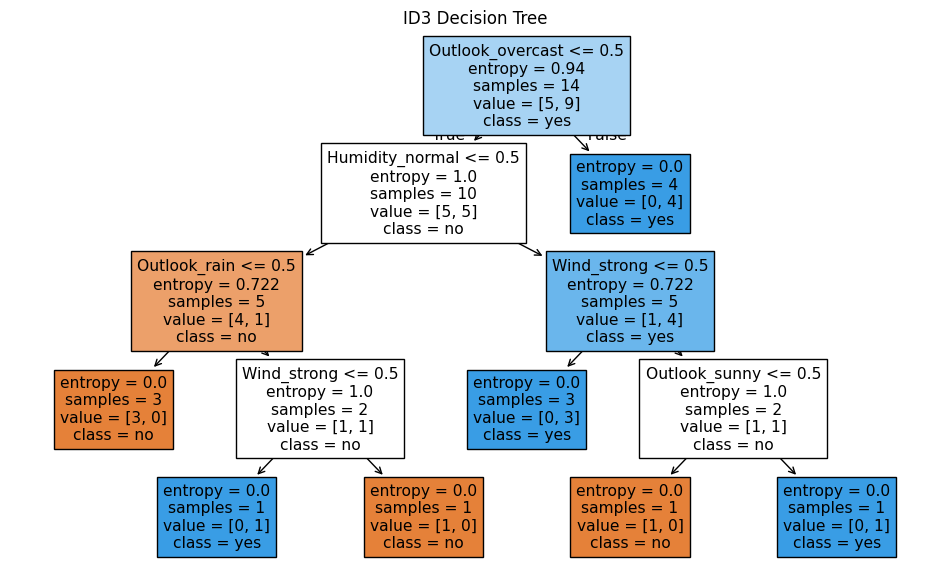

In [3]:
import pandas as pd
import math
from collections import Counter
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

data = pd.read_csv("play_tennis.csv")

def entropy(target):
    values = Counter(target)
    total = len(target)
    ent = 0

    for count in values.values():
        p = count / total
        ent -= p * math.log2(p)

    return ent

def information_gain(data, attribute, target):
    total_entropy = entropy(data[target])
    weighted_entropy = 0

    for value in data[attribute].unique():
        subset = data[data[attribute] == value]
        weighted_entropy += (len(subset) / len(data)) * entropy(subset[target])

    return total_entropy - weighted_entropy

target = "Target"

print("Dataset:")
print(data)

print("\nInformation Gain:")

for column in data.columns:
    if column != target:
        gain = information_gain(data, column, target)
        print(column, "=", round(gain, 4))

X = data.drop(target, axis=1)
y = data[target]

X = pd.get_dummies(X)

model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

model.fit(X, y)

new_sample = pd.DataFrame({
    "Outlook": ["sunny"],
    "Temperature": ["cool"],
    "Humidity": ["high"],
    "Wind": ["strong"]
})

new_sample = pd.get_dummies(new_sample)
new_sample = new_sample.reindex(columns=X.columns, fill_value=False)

prediction = model.predict(new_sample)

print("\nNew Sample:")
print(new_sample)

print("\nPredicted Class:", prediction[0])

accuracy = accuracy_score(y, model.predict(X))

print("\nAccuracy:", round(accuracy * 100, 2), "%")

plt.figure(figsize=(12, 7))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)

plt.title("ID3 Decision Tree")
plt.show()